# Analisis Descriptivo y Predictivo
## Estadisticas de Egresados 2009 - 2025

---

**Institucion:** Instituto Tecnologico de las Americas (ITLA)  
**Periodo de analisis:** Ultimos 10 años (2015 - 2025)  
**Tipo de analisis:** EDA · Visualizaciones · Ingenieria de Caracteristicas · Prediccion  

---
#Grupo 2
Edwin Pérez Santana 2024-0517

Idelsa Maria lugo Nivar 2024-0518

Angel Abreu 2024-0524

Luis González 2024-0509

---

### Contenido del Notebook
1. Instalacion e importacion de librerias
2. Carga y exploracion inicial del dataset
3. Limpieza y preprocesamiento de datos
4. Ingenieria de Caracteristicas
5. Analisis Exploratorio de Datos (EDA)
6. Visualizaciones Avanzadas
7. Analisis Predictivo
8. Conclusiones y Hallazgos

## 1. Instalacion e Importacion de Librerias

In [ ]:
# Instalacion de librerias adicionales
!pip install -q scikit-learn statsmodels plotly openpyxl

In [ ]:
# Importaciones generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Machine Learning y Series de Tiempo
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
# Estilo de graficas
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = ['#1B5E20','#2E7D32','#388E3C','#43A047','#66BB6A',
           '#A5D6A7','#F9A825','#E65100','#1565C0','#6A1B9A']
sns.set_palette(PALETTE)

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Carga y Exploracion Inicial del Dataset

In [ ]:
df_raw = pd.read_csv('/content/Estadisticas-egresados-2009-2025.csv', encoding='latin-1')
df_raw.head()

,Carrera,Masculino,Femenino,Mes de Graduacion,A¤o de graduacion
0,Tecn¢logo en Redes de la Informaci¢n,19,11,Agosto,2009
1,Tecn¢logoÿen Multimedia,1,9,Agosto,2009
2,Tecn¢logoÿen Manufactura Automatizada,4,5,Agosto,2009
3,Tecn¢logo en Desarrollo de Software,0,0,Agosto,2009
4,Tecn¢logo de Mecatr¢nica,0,0,Agosto,2009


In [ ]:
# Renombrar columnas para estandarizar
df_raw.columns = ['Carrera', 'Masculino', 'Femenino', 'Mes de graduación', 'Año de graduación']
df_raw

,Carrera,Masculino,Femenino,Mes de graduación,Año de graduación
0,Tecn¢logo en Redes de la Informaci¢n,19,11,Agosto,2009
1,Tecn¢logoÿen Multimedia,1,9,Agosto,2009
2,Tecn¢logoÿen Manufactura Automatizada,4,5,Agosto,2009
3,Tecn¢logo en Desarrollo de Software,0,0,Agosto,2009
4,Tecn¢logo de Mecatr¢nica,0,0,Agosto,2009
...,...,...,...,...,...
149,Tecnólogo en Multimedia,31,36,Octubre,2025
150,Tecnólogo en Redes de Información,2,0,Octubre,2025
151,Tecnólogo en Seguridad Informática,63,18,Octubre,2025
152,Tecnólogo en Sonido,4,0,Octubre,2025


In [ ]:
# Informacion general del dataset original
print('============================================================')
print('INFORMACION GENERAL DEL DATASET ORIGINAL (2009-2025)')
print('============================================================')
df_raw.info()
print()
print('Valores nulos por columna:')
df_raw.isnull().sum()
print()
print('Años disponibles en el dataset:')
sorted(df_raw['Año de graduación'].dropna().unique())

INFORMACION GENERAL DEL DATASET ORIGINAL (2009-2025)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Carrera            154 non-null    object
 1   Masculino          154 non-null    int64 
 2   Femenino           154 non-null    int64 
 3   Mes de graduación  154 non-null    object
 4   Año de graduación  154 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 6.1+ KB

Valores nulos por columna:

Años disponibles en el dataset:


[np.int64(2009),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [ ]:
import pandas as pd

df_raw["Carrera"] = (
    df_raw["Carrera"]
    .str.replace("¢", "ó")
    .str.replace("ÿ", " ")
)

df_raw

,Carrera,Masculino,Femenino,Mes de graduación,Año de graduación
0,Tecnólogo en Redes de la Información,19,11,Agosto,2009
1,Tecnólogo en Multimedia,1,9,Agosto,2009
2,Tecnólogo en Manufactura Automatizada,4,5,Agosto,2009
3,Tecnólogo en Desarrollo de Software,0,0,Agosto,2009
4,Tecnólogo de Mecatrónica,0,0,Agosto,2009
...,...,...,...,...,...
149,Tecnólogo en Multimedia,31,36,Octubre,2025
150,Tecnólogo en Redes de Información,2,0,Octubre,2025
151,Tecnólogo en Seguridad Informática,63,18,Octubre,2025
152,Tecnólogo en Sonido,4,0,Octubre,2025


In [ ]:
import unicodedata

def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = texto.replace("¢", "ó")
        texto = texto.replace("ÿ", " ")
        texto = texto.replace("¤", "ñ")
        texto = texto.replace("¡", "í")
        texto = texto.replace("", "é")
        texto = unicodedata.normalize("NFC", texto)
    return texto

df_raw["Carrera"] = df_raw["Carrera"].apply(limpiar_texto)

In [ ]:
def limpiar_texto(texto):
    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    texto = " ".join(texto.split())
    return texto

df_raw["Carrera"] = df_raw["Carrera"].astype(str).apply(limpiar_texto)

In [ ]:
df_raw = df_raw[df_raw["Año de graduación"] >= 2015]
df_raw

,Carrera,Masculino,Femenino,Mes de graduación,Año de graduación
35,Tecnologo en Redes de la Informacion,59,19,Agosto,2015
36,Tecnologo en Multimedia,44,35,Agosto,2015
37,Tecnologo en Manufactura Automatizada,20,4,Agosto,2015
38,Tecnologo en Desarrollo de Software,89,16,Agosto,2015
39,Tecnologo de Mecatronica,27,4,Agosto,2015
...,...,...,...,...,...
149,Tecnologo en Multimedia,31,36,Octubre,2025
150,Tecnologo en Redes de Informacion,2,0,Octubre,2025
151,Tecnologo en Seguridad Informatica,63,18,Octubre,2025
152,Tecnologo en Sonido,4,0,Octubre,2025


## 3. Limpieza y Preprocesamiento de Datos

In [ ]:
mapeo_carreras = {
# Redes
'Tecnologo en Redes de la Informacion': 'Tecnologo en Redes de la Informacion',
'Tecnologo en Redes de Informacion': 'Tecnologo en Redes de la Informacion',

# Software
'Tecnologo en Desarrollo de Software': 'Tecnologo en Desarrollo de Software',

# Multimedia
'Tecnologo en Multimedia': 'Tecnologo en Multimedia',

# Manufactura
'Tecnologo en Manufactura Automatizada': 'Tecnologo en Manufactura Automatizada',

# Mecatronica
'Tecnologo de Mecantronica': 'Tecnologo en Mecatronica',
'Tecnologo de Mecatronica': 'Tecnologo en Mecatronica',
'Tecnologo en Mecatronica': 'Tecnologo en Mecatronica',

# Seguridad
'Tecnologo en Seguridad Informatica': 'Tecnologo en Seguridad Informatica',

# Sonido
'Tecnologo en Sonido': 'Tecnologo en Sonido',

# Diseño
'Tecnologo en Diseno Industrial': 'Tecnologo en Diseno Industrial',
'Tecnologo en Disenio Industrial': 'Tecnologo en Diseno Industrial',

# Analitica
'Tecnologo en Analitica y Ciencia de los Datos': 'Tecnologo en Analitica y Ciencia de los Datos',

# IA
'Tecnologo en Inteligencia Artificial': 'Tecnologo en Inteligencia Artificial',

# Manufactura Medica
'Tecnologo en Manufactura de Dispositivos Medicos': 'Tecnologo en Manufactura de Dispositivos Medicos',

# Energias
'Tecnologo en Energias Renovables': 'Tecnologo en Energias Renovables',

# Forense
'Tecnologo en Informatica Forense': 'Tecnologo en Informatica Forense',

# Simulaciones (incluye errores)
'Tecnologo en Desarrollo de Sumulaciones Interactiva y Videojuego': 'Tecnologo en Desarrollo de Simulaciones Interactivas y Videojuegos',
'Tecnologo en Desarrollo de Simulaciones Interactivas y Videojuegos': 'Tecnologo en Desarrollo de Simulaciones Interactivas y Videojuegos',

# Telecom
'Tecnologo en Telecomunicaciones': 'Tecnologo en Telecomunicaciones',
}
df_raw["Carrera"] = df_raw["Carrera"].replace(mapeo_carreras)

In [ ]:
correcciones_extra = {
'Tecnologo en Seguridad Inform tica':
'Tecnologo en Seguridad Informatica',

'Tecnologo en Inform tica Forense':
'Tecnologo en Informatica Forense',

}
df_raw["Carrera"] = df_raw["Carrera"].replace(correcciones_extra)

In [ ]:
print(sorted(df_raw["Carrera"].unique()))
print("Total carreras:", df_raw["Carrera"].nunique())

['Tecnologo en Analitica y Ciencia de los Datos', 'Tecnologo en Desarrollo de Simulaciones Interactivas y Videojuegos', 'Tecnologo en Desarrollo de Software', 'Tecnologo en Diseno Industrial', 'Tecnologo en Energias Renovables', 'Tecnologo en Informatica Forense', 'Tecnologo en Inteligencia Artificial', 'Tecnologo en Manufactura Automatizada', 'Tecnologo en Manufactura de Dispositivos Medicos', 'Tecnologo en Mecatronica', 'Tecnologo en Multimedia', 'Tecnologo en Redes de la Informacion', 'Tecnologo en Seguridad Informatica', 'Tecnologo en Sonido', 'Tecnologo en Telecomunicaciones']
Total carreras: 15


In [ ]:
df_raw.value_counts("Carrera")

,count
Carrera,
Tecnologo en Desarrollo de Software,14
Tecnologo en Mecatronica,14
Tecnologo en Manufactura Automatizada,14
Tecnologo en Redes de la Informacion,14
Tecnologo en Multimedia,14
Tecnologo en Seguridad Informatica,10
Tecnologo en Sonido,8
Tecnologo en Diseno Industrial,6
Tecnologo en Analitica y Ciencia de los Datos,5


In [ ]:
ANO_INICIO = 2015
ANO_FIN = 2025

df = df_raw
df.value_counts("Carrera")

,count
Carrera,
Tecnologo en Desarrollo de Software,14
Tecnologo en Mecatronica,14
Tecnologo en Manufactura Automatizada,14
Tecnologo en Redes de la Informacion,14
Tecnologo en Multimedia,14
Tecnologo en Seguridad Informatica,10
Tecnologo en Sonido,8
Tecnologo en Diseno Industrial,6
Tecnologo en Analitica y Ciencia de los Datos,5


## 4. Ingenieria de Caracteristicas

In [ ]:
# Variables derivadas
df['Total'] = df['Masculino'] + df['Femenino']

# Mapeo de meses a numero
mes_map = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,
    'Junio':6,'Julio':7,'Agosto':8,'Septiembre':9,
    'Octubre':10,'Noviembre':11,'Diciembre':12
}
df['Mes_Num'] = df['Mes de graduación'].map(mes_map)
df['Fecha']   = pd.to_datetime(dict(year=df['Año de graduación'], month=df['Mes_Num'], day=1))

# Semestre de graduacion
df['Semestre'] = df['Mes_Num'].apply(
    lambda m: 'Primer Semestre' if m <= 6 else 'Segundo Semestre'
)

# Genero dominante por fila
df['Genero_Dom'] = df.apply(
    lambda r: 'Femenino' if r['Femenino'] > r['Masculino']
              else ('Masculino' if r['Masculino'] > r['Femenino'] else 'Igual'), axis=1
)

# Variable de tendencia para modelos predictivos (ano como indice numerico)
df['Ano_Idx'] = df['Año de graduación'] - ANO_INICIO

print('Ingenieria de caracteristicas completada')
print(f'Columnas generadas: {list(df.columns)}')
df

Ingenieria de caracteristicas completada
Columnas generadas: ['Carrera', 'Masculino', 'Femenino', 'Mes de graduación', 'Año de graduación', 'Total', 'Mes_Num', 'Fecha', 'Semestre', 'Genero_Dom', 'Ano_Idx']


,Carrera,Masculino,Femenino,Mes de graduación,Año de graduación,Total,Mes_Num,Fecha,Semestre,Genero_Dom,Ano_Idx
35,Tecnologo en Redes de la Informacion,59,19,Agosto,2015,78,8,2015-08-01,Segundo Semestre,Masculino,0
36,Tecnologo en Multimedia,44,35,Agosto,2015,79,8,2015-08-01,Segundo Semestre,Masculino,0
37,Tecnologo en Manufactura Automatizada,20,4,Agosto,2015,24,8,2015-08-01,Segundo Semestre,Masculino,0
38,Tecnologo en Desarrollo de Software,89,16,Agosto,2015,105,8,2015-08-01,Segundo Semestre,Masculino,0
39,Tecnologo en Mecatronica,27,4,Agosto,2015,31,8,2015-08-01,Segundo Semestre,Masculino,0
...,...,...,...,...,...,...,...,...,...,...,...
149,Tecnologo en Multimedia,31,36,Octubre,2025,67,10,2025-10-01,Segundo Semestre,Femenino,10
150,Tecnologo en Redes de la Informacion,2,0,Octubre,2025,2,10,2025-10-01,Segundo Semestre,Masculino,10
151,Tecnologo en Seguridad Informatica,63,18,Octubre,2025,81,10,2025-10-01,Segundo Semestre,Masculino,10
152,Tecnologo en Sonido,4,0,Octubre,2025,4,10,2025-10-01,Segundo Semestre,Masculino,10


In [ ]:
# Agregaciones base para analisis
by_year = df.groupby('Año de graduación').agg(
    Total     = ('Total',     'sum'),
    Masculino = ('Masculino', 'sum'),
    Femenino  = ('Femenino',  'sum')
).reset_index()

by_carrera = df.groupby('Carrera').agg(
    Masculino = ('Masculino', 'sum'),
    Femenino  = ('Femenino',  'sum'),
    Total     = ('Total',     'sum')
).reset_index().sort_values('Total', ascending=False)

by_cat_year = df.groupby(['Año de graduación'])['Total'].sum().reset_index()

print('Egresados por año (2015-2025):')
display(by_year)
print('\nEgresados por carrera (total periodo):')
display(by_carrera)

Egresados por año (2015-2025):


,Año de graduación,Total,Masculino,Femenino
0,2015,317,239,78
1,2016,324,194,130
2,2017,260,186,74
3,2018,263,56,207
4,2019,379,298,81
5,2020,227,189,38
6,2021,767,604,163
7,2022,546,427,119
8,2023,741,572,169
9,2024,608,466,142



Egresados por carrera (total periodo):


,Carrera,Masculino,Femenino,Total
2,Tecnologo en Desarrollo de Software,1630,688,2318
10,Tecnologo en Multimedia,483,431,914
12,Tecnologo en Seguridad Informatica,538,242,780
11,Tecnologo en Redes de la Informacion,467,174,641
9,Tecnologo en Mecatronica,297,115,412
7,Tecnologo en Manufactura Automatizada,96,35,131
0,Tecnologo en Analitica y Ciencia de los Datos,42,20,62
3,Tecnologo en Diseno Industrial,26,23,49
13,Tecnologo en Sonido,27,16,43
1,Tecnologo en Desarrollo de Simulaciones Intera...,9,15,24


## 5. Analisis Exploratorio de Datos (EDA)

In [ ]:
# Estadisticas descriptivas generales
print('============================================================')
print('ESTADISTICAS DESCRIPTIVAS (2015-2025)')
print('============================================================')
display(df[['Masculino','Femenino','Total']]
        .describe().round(2))

ESTADISTICAS DESCRIPTIVAS (2015-2025)


,Masculino,Femenino,Total
count,119.00,119.00,119.0
mean,30.67,15.03,45.7
std,43.38,27.51,57.6
min,0.00,0.00,1.0
25%,3.00,1.00,6.0
50%,14.00,5.00,20.0
75%,35.00,20.50,72.0
max,218.00,235.00,285.0


In [ ]:
# Conteo por variables categoricas
print('Distribucion por Semestre:')
print(df.groupby('Semestre')['Total'].sum().to_string())

Distribucion por Semestre:
Semestre
Primer Semestre     1224
Segundo Semestre    4214


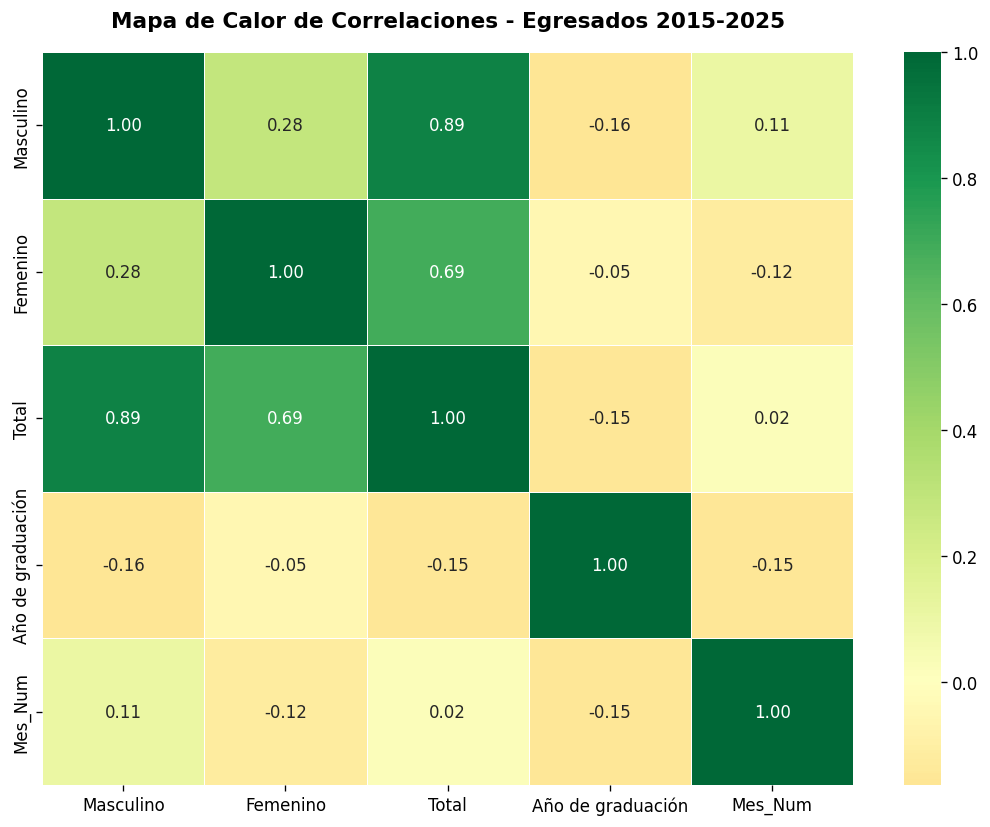

In [ ]:
# Mapa de calor de correlaciones
columnas_num = ['Masculino', 'Femenino', 'Total', 'Año de graduación', 'Mes_Num']
corr_matrix  = df[columnas_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 10}
)
ax.set_title('Mapa de Calor de Correlaciones - Egresados 2015-2025', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualizaciones Avanzadas

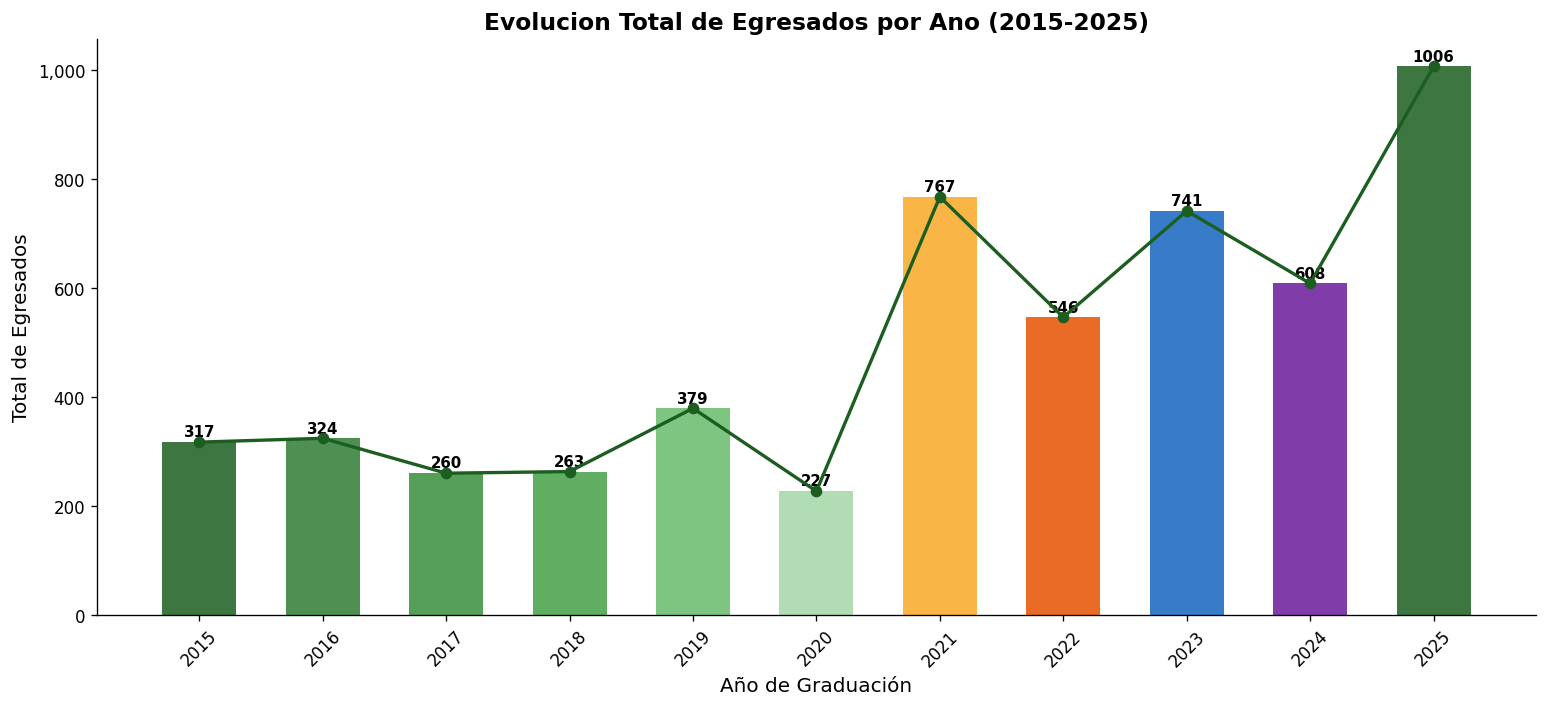

In [ ]:
# 6.1 Evolucion total de egresados por año
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(by_year['Año de graduación'], by_year['Total'],
              color=PALETTE[:len(by_year)], width=0.6, alpha=0.85)
ax.plot(by_year['Año de graduación'], by_year['Total'],
        marker='o', linewidth=2, color='#1B5E20', zorder=5)

for bar, v in zip(bars, by_year['Total']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Año de Graduación', fontsize=12)
ax.set_ylabel('Total de Egresados', fontsize=12)
ax.set_title('Evolucion Total de Egresados por Ano (2015-2025)', fontsize=14, fontweight='bold')
ax.set_xticks(by_year['Año de graduación'])
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('evolucion_total.png', dpi=150, bbox_inches='tight')
plt.show()

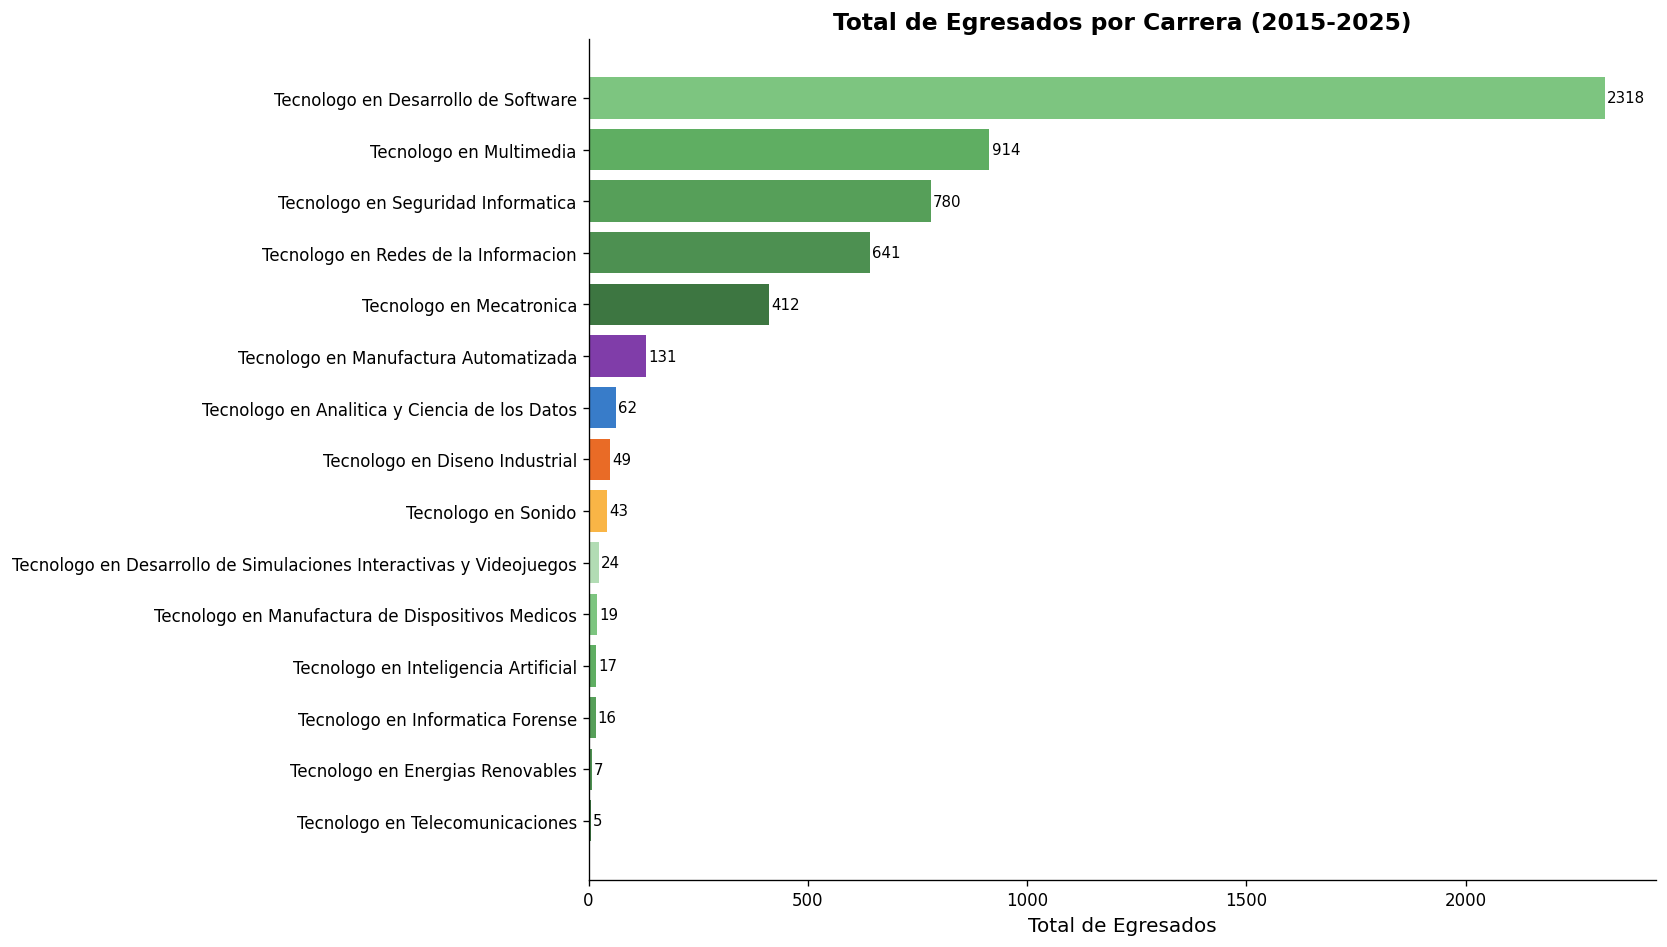

In [ ]:
# 6.2 Egresados por carrera (top carreras del periodo completo)
fig, ax = plt.subplots(figsize=(14, 8))

bc_plot = by_carrera.sort_values('Total', ascending=True)
colors  = [PALETTE[i % len(PALETTE)] for i in range(len(bc_plot))]

bars = ax.barh(bc_plot['Carrera'], bc_plot['Total'], color=colors, alpha=0.85)
for bar, v in zip(bars, bc_plot['Total']):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2, str(v),
            va='center', ha='left', fontsize=9)

ax.set_xlabel('Total de Egresados', fontsize=12)
ax.set_title('Total de Egresados por Carrera (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('egresados_por_carrera.png', dpi=150, bbox_inches='tight')
plt.show()

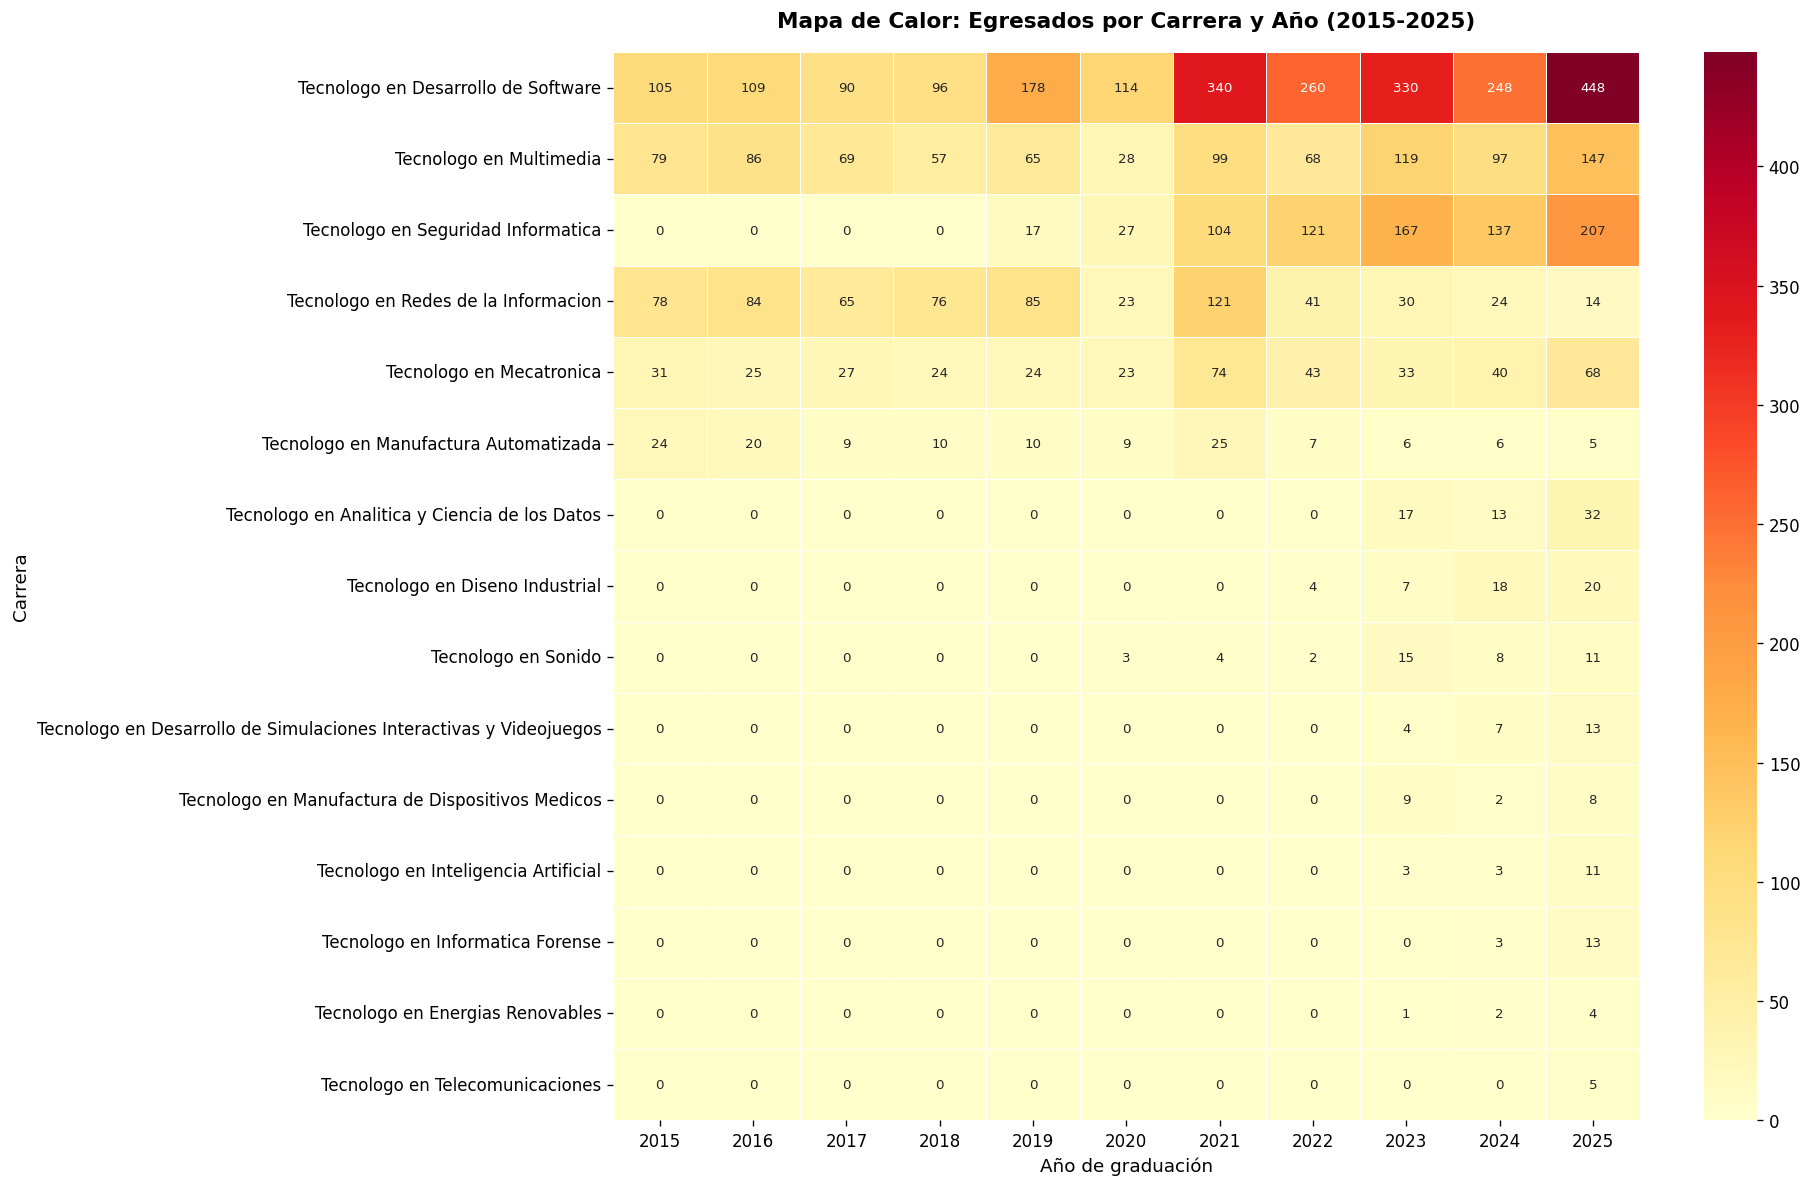

In [ ]:
# 6.5 Heatmap de egresados: Carrera x Ano
pivot_carrera_ano = df.pivot_table(
    index='Carrera', columns='Año de graduación', values='Total', aggfunc='sum'
).fillna(0).astype(int)

# Ordenar por total general
pivot_carrera_ano = pivot_carrera_ano.loc[
    pivot_carrera_ano.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot_carrera_ano,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Mapa de Calor: Egresados por Carrera y Año (2015-2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Año de graduación', fontsize=11)
ax.set_ylabel('Carrera', fontsize=11)
plt.tight_layout()
plt.savefig('heatmap_carrera_ano.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 6.6 Grafico interactivo Plotly: Evolucion por carrera
top_carreras = by_carrera.head(8)['Carrera'].tolist()
df_top = df[df['Carrera'].isin(top_carreras)]
df_top_year = df_top.groupby(['Año de graduación','Carrera'])['Total'].sum().reset_index()

fig_plotly = px.line(
    df_top_year, x='Año de graduación', y='Total', color='Carrera',
    markers=True,
    title='Evolucion de las 8 Carreras con mas Egresados (2015-2025)',
    labels={'Total':'Total Egresados','año':'Año de graduación'}
)
fig_plotly.update_layout(legend=dict(orientation='h', yanchor='bottom', y=-0.4))
fig_plotly.show()

## 7. Analisis Predictivo

## Regresión Lineal

In [ ]:
df_anual = (
    df_raw
    .groupby(["Carrera", "Año de graduación"])["Total"]
    .sum()
    .reset_index()
)
df_anual.sort_values("Total")

,Carrera,Año de graduación,Total
21,Tecnologo en Energias Renovables,2023,1
22,Tecnologo en Energias Renovables,2024,2
41,Tecnologo en Manufactura de Dispositivos Medicos,2024,2
85,Tecnologo en Sonido,2022,2
27,Tecnologo en Inteligencia Artificial,2024,3
...,...,...,...
15,Tecnologo en Desarrollo de Software,2024,248
13,Tecnologo en Desarrollo de Software,2022,260
14,Tecnologo en Desarrollo de Software,2023,330
12,Tecnologo en Desarrollo de Software,2021,340


In [ ]:
df_anual["Año_Idx"] = (
    df_anual["Año de graduación"] - df_anual["Año de graduación"].min()
)
df_anual.sort_values("Año_Idx")

,Carrera,Año de graduación,Total,Año_Idx
6,Tecnologo en Desarrollo de Software,2015,105,0
29,Tecnologo en Manufactura Automatizada,2015,24,0
54,Tecnologo en Multimedia,2015,79,0
43,Tecnologo en Mecatronica,2015,31,0
65,Tecnologo en Redes de la Informacion,2015,78,0
...,...,...,...,...
64,Tecnologo en Multimedia,2025,147,10
75,Tecnologo en Redes de la Informacion,2025,14,10
82,Tecnologo en Seguridad Informatica,2025,207,10
88,Tecnologo en Sonido,2025,11,10


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

predicciones = []

ano_min = df_anual["Año de graduación"].min()
idx_2026 = 2026 - ano_min

for carrera in df_anual["Carrera"].unique():

    datos = df_anual[df_anual["Carrera"] == carrera]

    X = datos[["Año_Idx"]]
    y = datos["Total"]

    modelo = LinearRegression()
    modelo.fit(X, y)

    pred = modelo.predict([[idx_2026]])[0]

    predicciones.append({
        "Carrera": carrera,
        "Prediccion_2026": round(max(pred,0))
    })

df_pred = pd.DataFrame(predicciones)

In [ ]:
df_pred.sort_values("Prediccion_2026", ascending=False)

,Carrera,Prediccion_2026
2,Tecnologo en Desarrollo de Software,401
12,Tecnologo en Seguridad Informatica,233
10,Tecnologo en Multimedia,115
9,Tecnologo en Mecatronica,57
0,Tecnologo en Analitica y Ciencia de los Datos,36
3,Tecnologo en Diseno Industrial,27
5,Tecnologo en Informatica Forense,23
11,Tecnologo en Redes de la Informacion,20
1,Tecnologo en Desarrollo de Simulaciones Intera...,17
13,Tecnologo en Sonido,14


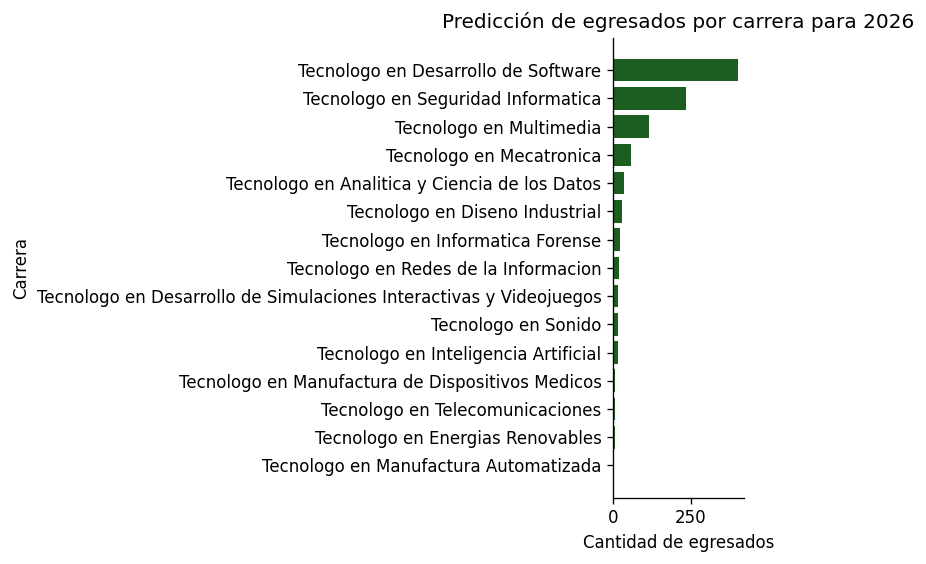

In [ ]:
# Ordenar por predicción
df_pred = df_pred.sort_values("Prediccion_2026")

plt.figure()

plt.barh(df_pred["Carrera"], df_pred["Prediccion_2026"])

plt.title("Predicción de egresados por carrera para 2026")
plt.xlabel("Cantidad de egresados")
plt.ylabel("Carrera")

plt.tight_layout()

plt.show()

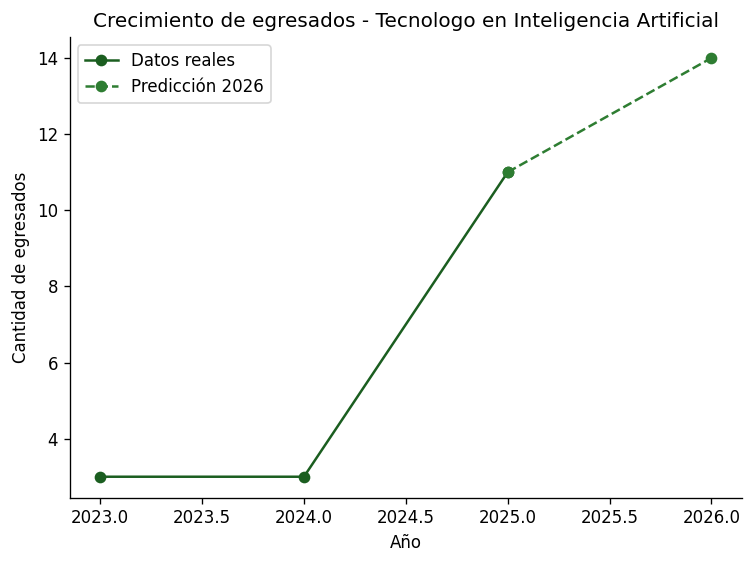

In [ ]:
carrera = "Tecnologo en Inteligencia Artificial"

# Datos históricos
hist = df_anual[df_anual["Carrera"] == carrera].sort_values("Año de graduación")

# Predicción
pred_2026 = df_pred[df_pred["Carrera"] == carrera]["Prediccion_2026"].values[0]

# Crear nuevo dataframe con predicción
df_plot = hist.copy()

df_pred_row = pd.DataFrame({
    "Carrera":[carrera],
    "Año de graduación":[2026],
    "Total":[pred_2026]
})

df_plot = pd.concat([df_plot, df_pred_row])

# Graficar
plt.figure()

plt.plot(hist["Año de graduación"], hist["Total"], marker='o', label="Datos reales")

plt.plot([2025, 2026],
         [hist["Total"].iloc[-1], pred_2026],
         marker='o',
         linestyle='--',
         label="Predicción 2026")

plt.title(f"Crecimiento de egresados - {carrera}")
plt.xlabel("Año")
plt.ylabel("Cantidad de egresados")

plt.legend()

plt.tight_layout()
plt.show()

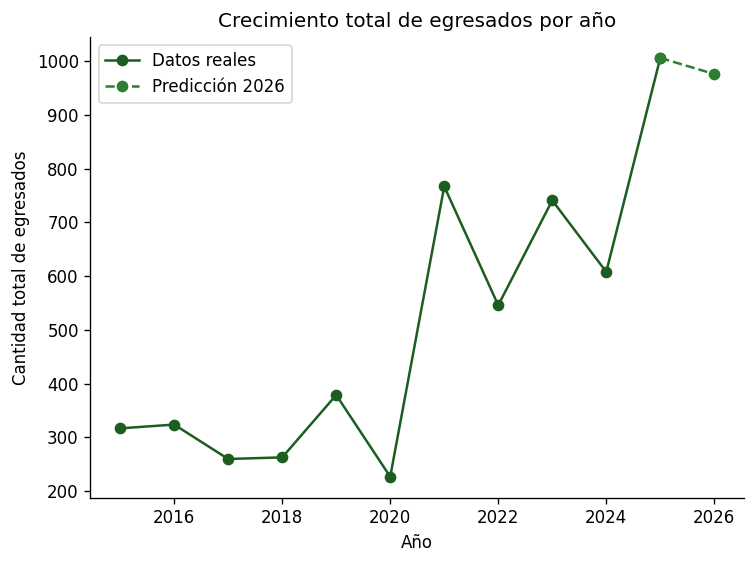

In [ ]:
# Total de egresados por año (todas las carreras)
totales_anuales = (
    df_anual.groupby("Año de graduación")["Total"]
    .sum()
    .reset_index()
)

# Total predicho para 2026
pred_total_2026 = df_pred["Prediccion_2026"].sum()

# Crear dataframe con la predicción
pred_row = pd.DataFrame({
    "Año de graduación":[2026],
    "Total":[pred_total_2026]
})

# Dataset para graficar
df_plot = pd.concat([totales_anuales, pred_row])

# Graficar
plt.figure()

# Datos reales
plt.plot(
    totales_anuales["Año de graduación"],
    totales_anuales["Total"],
    marker="o",
    label="Datos reales"
)

# Predicción
plt.plot(
    [totales_anuales["Año de graduación"].iloc[-1], 2026],
    [totales_anuales["Total"].iloc[-1], pred_total_2026],
    linestyle="--",
    marker="o",
    label="Predicción 2026"
)

plt.title("Crecimiento total de egresados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad total de egresados")

plt.legend()

plt.tight_layout()
plt.show()

## Holt-Winters

In [ ]:
# 1. Crear DataFrame anual (agrupando todos los meses)
df_anual = df.groupby('Año de graduación')['Total'].sum().reset_index()
df_anual.columns = ['año', 'total_graduados']
df_anual = df_anual.sort_values('año')

print(" DATOS ANUALES DE GRADUADOS")
print(df_anual)
print(f"\n Total 2025: {df_anual[df_anual['año']==2025]['total_graduados'].values[0]}")

 DATOS ANUALES DE GRADUADOS
     año  total_graduados
0   2015              317
1   2016              324
2   2017              260
3   2018              263
4   2019              379
5   2020              227
6   2021              767
7   2022              546
8   2023              741
9   2024              608
10  2025             1006

 Total 2025: 1006


In [ ]:
# 2. Preparar datos para el modelo
y = df_anual['total_graduados'].values
años = df_anual['año'].values

# 3. Modelo Holt-Winters (solo tendencia, sin estacionalidad)
modelo = ExponentialSmoothing(
    y,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
)

# 4. Ajustar modelo
resultado = modelo.fit()

# 5. Predecir 2026
prediccion_2026 = resultado.forecast(1)[0]

print("\n PREDICCIÓN 2026")
print(f" Total estimado de graduados en 2026: {prediccion_2026:.0f} estudiantes")


 PREDICCIÓN 2026
 Total estimado de graduados en 2026: 875 estudiantes


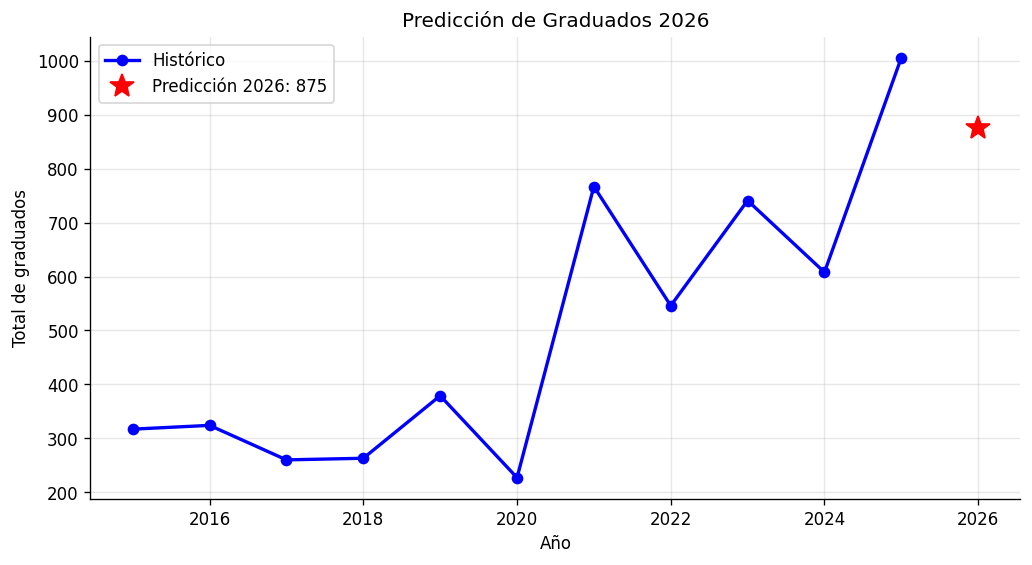


 RESULTADO FINAL: 875 estudiantes se graduarán en 2026


In [ ]:
# 6. Visualización básica
plt.figure(figsize=(10, 5))
plt.plot(años, y, 'o-', color='blue', linewidth=2, label='Histórico')
plt.plot(2026, prediccion_2026, 'r*', markersize=15, label=f'Predicción 2026: {prediccion_2026:.0f}')
plt.title('Predicción de Graduados 2026')
plt.xlabel('Año')
plt.ylabel('Total de graduados')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 7. Mostrar predicción por si sola
print(f"\n RESULTADO FINAL: {prediccion_2026:.0f} estudiantes se graduarán en 2026")

### Nueva sección

In [ ]:
print("="*50)
print(" COMPARACIÓN DE MODELOS")
print("="*50)

# 1. MÉTRICAS DEL MODELO HOLT-WINTERS
# ------------------------------------
predicciones_train_hw = resultado.fittedvalues

# 'y' was used for training the Holt-Winters model
mae_hw = mean_absolute_error(y, predicciones_train_hw)
rmse_hw = np.sqrt(mean_squared_error(y, predicciones_train_hw))
r2_hw = r2_score(y, predicciones_train_hw)

print("\n MODELO HOLT-WINTERS:")
print(f"   MAE:  {mae_hw:.2f}")
print(f"   RMSE: {rmse_hw:.2f}")
print(f"   R²:   {r2_hw:.4f}")
print(f"   AIC:  {resultado.aic:.2f}")

# 2. MÉTRICAS DEL MODELO REGRESIÓN LINEAL POR CARRERA

df_anual_lr = (
    df_raw
    .groupby(["Carrera", "Año de graduación"])["Total"]
    .sum()
    .reset_index()
)
df_anual_lr["Año_Idx"] = (
    df_anual_lr["Año de graduación"] - df_anual_lr["Año de graduación"].min()
)

predicciones_reales = []
predicciones_lineales = []

for carrera in df_anual_lr["Carrera"].unique():
    datos = df_anual_lr[df_anual_lr["Carrera"] == carrera]

    # Solo procesar si hay suficientes datos
    if len(datos) >= 2:
        X = datos[["Año_Idx"]].values
        y_carrera = datos["Total"].values

        modelo_lr = LinearRegression()
        modelo_lr.fit(X, y_carrera)

        # Predecir para cada año en los datos
        preds = modelo_lr.predict(X)

        for i in range(len(datos)):
            predicciones_reales.append(y_carrera[i])
            predicciones_lineales.append(max(preds[i], 0))

# Calcular métricas globales para regresión lineal
if len(predicciones_reales) > 0:
    mae_lr = mean_absolute_error(predicciones_reales, predicciones_lineales)
    rmse_lr = np.sqrt(mean_squared_error(predicciones_reales, predicciones_lineales))
    r2_lr = r2_score(predicciones_reales, predicciones_lineales)
else:
    mae_lr = rmse_lr = r2_lr = 0

print("\n MODELO REGRESIÓN LINEAL (por carrera):")
print(f"   MAE:  {mae_lr:.2f}")
print(f"   RMSE: {rmse_lr:.2f}")
print(f"   R²:   {r2_lr:.4f}")
print(f"   Muestras totales: {len(predicciones_reales)}")

# 3. COMPARACIÓN DIRECTA
# ----------------------
print("\n" + "="*50)
print(" COMPARACIÓN DIRECTA")
print("="*50)

print(f"\n{'Métrica':<15} {'Holt-Winters':<20} {'Regresión Lineal':<20}")
print("-"*55)
print(f"{'MAE':<15} {mae_hw:<20.2f} {mae_lr:<20.2f}")
print(f"{'RMSE':<15} {rmse_hw:<20.2f} {rmse_lr:<20.2f}")
print(f"{'R²':<15} {r2_hw:<20.4f} {r2_lr:<20.4f}")

# 4. PREDICCIÓN 2026
# ------------------------
# Calcular predicción de regresión lineal sumando carreras
df_pred = pd.DataFrame(predicciones)

print(f"\n PREDICCIÓN 2026:")
print(f"   Holt-Winters: {prediccion_2026:.0f} estudiantes")
print(f"   Regresión Lineal (suma por carrera): {df_pred['Prediccion_2026'].sum():.0f} estudiantes")
print(f"   Diferencia: {abs(prediccion_2026 - df_pred['Prediccion_2026'].sum()):.0f} estudiantes")


 COMPARACIÓN DE MODELOS

 MODELO HOLT-WINTERS:
   MAE:  124.21
   RMSE: 142.57
   R²:   0.6644
   AIC:  117.12

 MODELO REGRESIÓN LINEAL (por carrera):
   MAE:  14.80
   RMSE: 26.08
   R²:   0.8961
   Muestras totales: 89

 COMPARACIÓN DIRECTA

Métrica         Holt-Winters         Regresión Lineal    
-------------------------------------------------------
MAE             124.21               14.80               
RMSE            142.57               26.08               
R²              0.6644               0.8961              

 PREDICCIÓN 2026:
   Holt-Winters: 875 estudiantes
   Regresión Lineal (suma por carrera): 976 estudiantes
   Diferencia: 101 estudiantes


## 8. Conclusiones y Hallazgos


**CONCLUSIONES Y HALLAZGOS - EGRESADOS ITLA 2015-2025**
============================================================

1. VOLUMEN TOTAL
   Total de egresados en el periodo 2015-2025: 5,438

   Año con mayor graduacion: 2025 con 1,006 egresados

   Año con menor graduacion: 2020 con 227 egresados

2. CARRERA DOMINANTE

   La carrera con mas egresados en el periodo es: Tecnologo en Desarrollo de Software (2,318 egresados)

   Representa el 42.6% del total de egresados

3. PREDICCION 2026

   Proyeccion de egresados para 2026 (Regresion Lineal): 976 estudiantes

   Proyeccion de egresados para 2026 (Holt-Winters): 875 estudiantes

   Diferencia entre modelos: 101 estudiantes

4. NUEVAS CARRERAS

   Desde 2019 se incorporaron programas de Seguridad Informatica,
   Analitica y Ciencia de Datos, Inteligencia Artificial,
   Manufactura de Dispositivos Medicos y Simulaciones y Videojuegos,
   reflejando la adaptacion de la institucion a las demandas del mercado.

### CONCLUSIÓN
**El modelo de REGRESIÓN LINEAL por carrera es claramente superior:**

1. Error mucho menor: Se equivoca en promedio por 15 estudiantes vs 124 del modelo Holt-Winters

2. Mayor precisión: R² de 0.90 vs 0.66 (explica mejor los datos)

3. Más estable: RMSE de 26.1 vs 142.6, lo que indica menos errores grandes

COMPARATIVA DE MODELOS:
   • Regresión Lineal: MAE = 14.8 | RMSE = 26.1 | R² = 0.90
   • Holt-Winters:    MAE = 124.2 | RMSE = 142.6 | R² = 0.66

PREDICCIÓN FINAL RECOMENDADA PARA 2026: **976 estudiantes**